In [54]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho base dos dados
BASE = r"CDAF - bases de dados e codigos de apoio\Wyscout"
CITY_ID = 1625

In [55]:
df_events = pd.DataFrame()
for i in range(1, 14):
    path = os.path.join(BASE, f'events_England_{i}.json')
    with open(path) as f:
        data = json.load(f)
    df_events = pd.concat([df_events, pd.DataFrame(data)])

print(f"Total de eventos: {len(df_events)}")
print(df_events['eventName'].value_counts())

Total de eventos: 643150
eventName
Pass                       328657
Duel                       176688
Others on the ball          51085
Free Kick                   36423
Interruption                27535
Shot                         8451
Foul                         8138
Save attempt                 3349
Offside                      1558
Goalkeeper leaving line      1266
Name: count, dtype: int64


In [56]:
with open(os.path.join(BASE, 'matches_England.json')) as f:
    matches = json.load(f)
df_matches = pd.DataFrame(matches)

# Jogos onde o City participou
city_matches = df_matches[
    (df_matches['teamsData'].apply(lambda x: str(CITY_ID) in str(x)))
]
city_match_ids = city_matches['wyId'].tolist()
print(f"Jogos do Man City encontrados: {len(city_match_ids)}")

Jogos do Man City encontrados: 38


In [57]:
def get_x(positions):
    # Extrair coordenada X de início do evento
    try:
        return positions[0]['x']
    except:
        return None

In [58]:
def get_result(team_id, match_id, df_matches):
    try:
        teams_data = df_matches[df_matches['wyId'] == match_id].iloc[0]['teamsData']
        scores = {int(tid): tdata['score'] for tid, tdata in teams_data.items()}
        city_score = scores[team_id]
        opp_score = [v for k, v in scores.items() if k != team_id][0]
        if city_score > opp_score:
            return 'Vitória'
        elif city_score == opp_score:
            return 'Empate'
        else:
            return 'Derrota'
    except:
        return None

In [59]:
def calcula_altura_bloco(df_events, match_ids, team_id):
    eventos = df_events[df_events['matchId'].isin(match_ids)].copy()
    eventos['x'] = eventos['positions'].apply(get_x)

    # Pegar só eventos do ADVERSÁRIO (não do City)
    # e só ações defensivas
    eventos_adversario = eventos[
        (eventos['teamId'] != team_id) &
        (eventos['eventName'].isin(['Duel', 'Interruption', 'Free Kick']))
    ].copy()

    # Calcular mediana do X por jogo
    altura_bloco = eventos_adversario.groupby('matchId')['x'].median().reset_index()
    altura_bloco.columns = ['matchId', 'mediana_x']

    # Classificar bloco (X alto = defende perto do City = bloco baixo)
    altura_bloco['tipo_bloco'] = pd.cut(
        altura_bloco['mediana_x'],
        bins=[30, 40, 50, 70],
        labels=['Bloco Alto', 'Bloco Médio', 'Bloco Baixo']
    )

    return eventos_adversario, altura_bloco

In [60]:
def calcula_kpis(df_events, match_ids, team_id):
    eventos_ataque = df_events[
        (df_events['matchId'].isin(match_ids)) &
        (df_events['teamId'] == team_id)
    ].copy()

    kpis = eventos_ataque.groupby('matchId').agg(
        total_passes=('eventName', lambda x: (x == 'Pass').sum()),
        total_chutes=('eventName', lambda x: (x == 'Shot').sum()),
    ).reset_index()

    return kpis

In [61]:
eventos_adversario, altura_bloco = calcula_altura_bloco(df_events, city_match_ids, CITY_ID)

matches_info = df_matches[df_matches['wyId'].isin(city_match_ids)][['wyId', 'label']].copy()
altura_bloco = pd.merge(altura_bloco, matches_info, left_on='matchId', right_on='wyId').drop(columns='wyId')

altura_bloco = altura_bloco[['matchId', 'label', 'mediana_x', 'tipo_bloco']]
altura_bloco.columns = ['matchId', 'Confronto (Equipes e Placar)', 'Mediana X', 'Tipo de Defesa']

altura_bloco['Resultado'] = altura_bloco['matchId'].apply(
    lambda mid: get_result(CITY_ID, mid, df_matches)
)

resumo = altura_bloco.groupby('Tipo de Defesa')['Resultado'].agg(
    Total='count',
    Vitórias=lambda x: (x == 'Vitória').sum(),
    Empates=lambda x: (x == 'Empate').sum(),
    Derrotas=lambda x: (x == 'Derrota').sum()
).reindex(['Bloco Alto', 'Bloco Médio', 'Bloco Baixo'])

matches_info['Resultado'] = matches_info['wyId'].apply(
    lambda mid: get_result(CITY_ID, mid, df_matches)
)

resumo_geral = matches_info['Resultado'].value_counts().rename({
    'Vitória': 'Vitórias',
    'Empate': 'Empates',
    'Derrota': 'Derrotas'
})

print("Desempenho Geral do Manchester City")
print(resumo_geral.to_string())
print(f"\nTotal de jogos: {len(matches_info)}")
print("\nDesempenho por Tipo de Defesa")
print(resumo.to_string())
altura_bloco.head(10)

Desempenho Geral do Manchester City
Resultado
Vitórias    32
Empates      4
Derrotas     2

Total de jogos: 38

Desempenho por Tipo de Defesa
                Total  Vitórias  Empates  Derrotas
Tipo de Defesa                                    
Bloco Alto         18        18        0         0
Bloco Médio        14        11        2         1
Bloco Baixo         6         3        2         1


,matchId,Confronto (Equipes e Placar),Mediana X,Tipo de Defesa,Resultado
0,2499720,"Brighton & Hove Albion - Manchester City, 0 - 2",35.0,Bloco Alto,Vitória
1,2499734,"Manchester City - Everton, 1 - 1",57.0,Bloco Baixo,Empate
2,2499739,"AFC Bournemouth - Manchester City, 1 - 2",37.0,Bloco Alto,Vitória
3,2499754,"Manchester City - Liverpool, 5 - 0",43.0,Bloco Médio,Vitória
4,2499767,"Watford - Manchester City, 0 - 6",34.5,Bloco Alto,Vitória
5,2499774,"Manchester City - Crystal Palace, 5 - 0",39.5,Bloco Alto,Vitória
6,2499781,"Chelsea - Manchester City, 0 - 1",39.0,Bloco Alto,Vitória
7,2499794,"Manchester City - Stoke City, 7 - 2",39.0,Bloco Alto,Vitória
8,2499802,"Manchester City - Burnley, 3 - 0",49.0,Bloco Médio,Vitória
9,2499818,"West Bromwich Albion - Manchester City, 2 - 3",40.0,Bloco Alto,Vitória


In [62]:
kpis = calcula_kpis(df_events, city_match_ids, CITY_ID)

df_analise = altura_bloco.merge(kpis, on='matchId')
df_analise.head()

,matchId,Confronto (Equipes e Placar),Mediana X,Tipo de Defesa,Resultado,total_passes,total_chutes
0,2499720,"Brighton & Hove Albion - Manchester City, 0 - 2",35.0,Bloco Alto,Vitória,754,12
1,2499734,"Manchester City - Everton, 1 - 1",57.0,Bloco Baixo,Empate,521,18
2,2499739,"AFC Bournemouth - Manchester City, 1 - 2",37.0,Bloco Alto,Vitória,606,17
3,2499754,"Manchester City - Liverpool, 5 - 0",43.0,Bloco Médio,Vitória,717,13
4,2499767,"Watford - Manchester City, 0 - 6",34.5,Bloco Alto,Vitória,631,25


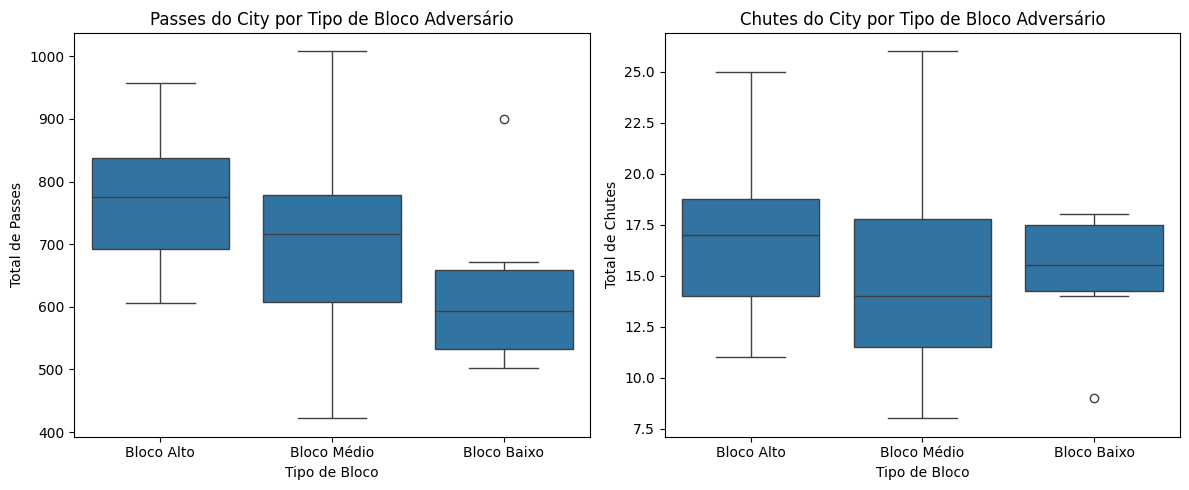

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Passes por tipo de bloco (Fixed x='Tipo de Defesa')
sns.boxplot(data=df_analise, x='Tipo de Defesa', y='total_passes', ax=axes[0])
axes[0].set_title('Passes do City por Tipo de Bloco Adversário')
axes[0].set_xlabel('Tipo de Bloco')
axes[0].set_ylabel('Total de Passes')

# Chutes por tipo de bloco (Fixed x='Tipo de Defesa')
sns.boxplot(data=df_analise, x='Tipo de Defesa', y='total_chutes', ax=axes[1])
axes[1].set_title('Chutes do City por Tipo de Bloco Adversário')
axes[1].set_xlabel('Tipo de Bloco')
axes[1].set_ylabel('Total de Chutes')

plt.tight_layout()
plt.savefig('analise_city.png', dpi=150)
plt.show()

In [64]:
# Ver a distribuição geral do X dos eventos adversários
print(eventos_adversario['x'].describe())
print()
# Ver exemplos de um jogo específico
jogo_exemplo = city_match_ids[0]
sample = eventos_adversario[eventos_adversario['matchId'] == jogo_exemplo][['eventName','x']].head(20)
print(sample)
print()
print("Mediana X desse jogo:", eventos_adversario[eventos_adversario['matchId'] == jogo_exemplo]['x'].median())

count    11303.000000
mean        45.566487
std         29.321616
min          0.000000
25%         22.000000
50%         42.000000
75%         69.000000
max        100.000000
Name: x, dtype: float64

          eventName   x
36822          Duel  21
36824  Interruption  15
36825     Free Kick  11
36826          Duel  31
36830  Interruption  55
36843  Interruption  25
36858          Duel  25
36863  Interruption  66
36864     Free Kick  68
36866  Interruption  99
36868          Duel  33
36872          Duel  42
36883          Duel  69
36885          Duel  66
36886          Duel  68
36890          Duel  62
36905          Duel  37
36916          Duel  29
36918          Duel  28
36923          Duel  82

Mediana X desse jogo: 42.0


In [ ]:
# Big Six teams: Arsenal, Chelsea, Liverpool, Manchester United and Tottenham Hotspur
BIG_SIX_IDS = [1609, 1610, 1611, 1612, 1624, 1625]
CITY_ID = 1625

big_six_opponents = [t_id for t_id in BIG_SIX_IDS if t_id != CITY_ID]

def is_big_six_clash(teams_data):
    match_team_ids = [int(team_id) for team_id in teams_data.keys()]

    if CITY_ID in match_team_ids:
        if any(opp_id in match_team_ids for opp_id in big_six_opponents):
            return True
    return False

city_big_six_matches = df_matches[df_matches['teamsData'].apply(is_big_six_clash)].copy()

big_six_match_ids =     ['wyId'].tolist()

In [66]:
matches_big6_info = (
    df_matches[df_matches['wyId'].isin(big_six_match_ids)][['wyId', 'label']]
    .copy()
)

_, altura_bloco_big6 = calcula_altura_bloco(df_events, big_six_match_ids, CITY_ID)

analise_big6 = pd.merge(
    matches_big6_info,
    altura_bloco_big6,
    left_on='wyId',
    right_on='matchId'
)

analise_big6['Resultado'] = analise_big6['matchId'].apply(
    lambda mid: get_result(CITY_ID, mid, df_matches)
)

resumo_big6 = analise_big6.groupby('tipo_bloco')['Resultado'].agg(
    Total='count',
    Vitórias=lambda x: (x == 'Vitória').sum(),
    Empates=lambda x: (x == 'Empate').sum(),
    Derrotas=lambda x: (x == 'Derrota').sum()
).reindex(['Bloco Alto', 'Bloco Médio', 'Bloco Baixo'])

print(resumo_big6.to_string())

analise_big6 = (
    analise_big6[['label', 'mediana_x', 'tipo_bloco', 'Resultado']]
    .sort_values(by='tipo_bloco')
    .reset_index(drop=True)
)

analise_big6.columns = ['Confronto (Equipes e Placar)', 'Mediana X', 'Tipo de Defesa', 'Resultado']

display(analise_big6)

             Total  Vitórias  Empates  Derrotas
tipo_bloco                                     
Bloco Alto       2         2        0         0
Bloco Médio      5         4        0         1
Bloco Baixo      3         2        0         1


,Confronto (Equipes e Placar),Mediana X,Tipo de Defesa,Resultado
0,"Manchester City - Chelsea, 1 - 0",34.0,Bloco Alto,Vitória
1,"Chelsea - Manchester City, 0 - 1",39.0,Bloco Alto,Vitória
2,"Liverpool - Manchester City, 4 - 3",46.0,Bloco Médio,Derrota
3,"Manchester City - Tottenham Hotspur, 4 - 1",46.0,Bloco Médio,Vitória
4,"Manchester United - Manchester City, 1 - 2",46.0,Bloco Médio,Vitória
5,"Manchester City - Arsenal, 3 - 1",47.0,Bloco Médio,Vitória
6,"Manchester City - Liverpool, 5 - 0",43.0,Bloco Médio,Vitória
7,"Tottenham Hotspur - Manchester City, 1 - 3",53.0,Bloco Baixo,Vitória
8,"Manchester City - Manchester United, 2 - 3",54.0,Bloco Baixo,Derrota
9,"Arsenal - Manchester City, 0 - 3",62.0,Bloco Baixo,Vitória


In [67]:
def calcula_kpis_com_gols(df_events, match_ids, team_id):
    # Filtra apenas eventos do Manchester City nos jogos selecionados
    eventos_city = df_events[
        (df_events['matchId'].isin(match_ids)) & 
        (df_events['teamId'] == team_id)
    ].copy()
    
    # Função auxiliar para contar gols dentro dos eventos de chute (Shot) ou pênalti
    def contar_gols(eventos_do_jogo):
        gols = 0
        for _, env in eventos_do_jogo.iterrows():
            # Verifica se o evento é um Chute (Shot) ou Pênalti (Free Kick com sub-id de pênalti se houver)
            if env['eventName'] in ['Shot', 'Free Kick']:
                # No Wyscout, o ID de tag 101 significa "Goal"
                tags = [tag['id'] for tag in env.get('tags', [])]
                if 101 in tags:
                    gols += 1
        return gols

    # Agrupa por jogo para calcular os KPIs
    kpis = eventos_city.groupby('matchId').agg(
        total_chutes=('eventName', lambda x: (x == 'Shot').sum()),
    ).reset_index()
    
    # Calcula os gols por jogo usando a nossa função auxiliar
    gols_por_jogo = eventos_city.groupby('matchId').apply(contar_gols).reset_index(name='total_gols')
    
    # Junta as duas informações
    kpis_completos = pd.merge(kpis, gols_por_jogo, on='matchId')
    return kpis_completos

# 1. Calcula os novos KPIs (Chutes e Gols)
df_kpis_novos = calcula_kpis_com_gols(df_events, city_match_ids, CITY_ID)

# 2. Junta com a tabela de blocos defensivos que você já tinha calculado
df_correlacao = altura_bloco.merge(df_kpis_novos, on='matchId')

# 3. Exibe a tabela detalhada para conferência
print("--- Dados por Jogo (Amostra) ---")
display(df_correlacao[['Confronto (Equipes e Placar)', 'Tipo de Defesa', 'total_chutes', 'total_gols']].head())

# 4. Calcula a Correlação de Pearson entre Chutes e Gols
correlacao_chute_gol = df_correlacao['total_chutes'].corr(df_correlacao['total_gols'])
print(f"\n=========================================")
print(f"CORRELAÇÃO ENTRE CHUTES E GOLS: {correlacao_chute_gol:.2f}")
print(f"=========================================")
if correlacao_chute_gol > 0.5:
    print("-> Forte correlação: Mais chutes costumam significar mais gols.")
else:
    print("-> Correlação fraca: Dar mais chutes não necessariamente se traduz em mais gols.")

# 5. Agrupa por Tipo de Defesa para responder à pergunta do Lucas
print("\n--- Média de Chutes e Gols por Tipo de Bloco Defensivo ---")
analise_bloco = df_correlacao.groupby('Tipo de Defesa', observed=False).agg(
    Jogos=('matchId', 'count'),
    Media_Chutes=('total_chutes', 'mean'),
    Media_Gols=('total_gols', 'mean'),
    Total_Gols=('total_gols', 'sum')
).reindex(['Bloco Alto', 'Bloco Médio', 'Bloco Baixo'])

display(analise_bloco)

--- Dados por Jogo (Amostra) ---


,Confronto (Equipes e Placar),Tipo de Defesa,total_chutes,total_gols
0,"Brighton & Hove Albion - Manchester City, 0 - 2",Bloco Alto,12,1
1,"Manchester City - Everton, 1 - 1",Bloco Baixo,18,1
2,"AFC Bournemouth - Manchester City, 1 - 2",Bloco Alto,17,2
3,"Manchester City - Liverpool, 5 - 0",Bloco Médio,13,5
4,"Watford - Manchester City, 0 - 6",Bloco Alto,25,6



CORRELAÇÃO ENTRE CHUTES E GOLS: 0.32
-> Correlação fraca: Dar mais chutes não necessariamente se traduz em mais gols.

--- Média de Chutes e Gols por Tipo de Bloco Defensivo ---


,Jogos,Media_Chutes,Media_Gols,Total_Gols
Tipo de Defesa,,,,
Bloco Alto,18,16.944444,2.888889,52
Bloco Médio,14,14.857143,2.571429,36
Bloco Baixo,6,15.000000,2.333333,14


In [68]:
import pandas as pd
import numpy as np

# ==============================================================================
# ABORDAGEM 1 & 2: INTENSIDADE (PPDA) E EFICIÊNCIA DE DUELOS POR JOGO
# ==============================================================================
def calcula_metricas_defensivas_jogo(df_events, match_ids, team_id):
    resultados_jogos = []
    
    for mid in match_ids:
        # Filtra eventos do jogo atual
        ev_jogo = df_events[df_events['matchId'] == mid].copy()
        
        # ----------------------------------------------------------------------
        # 1. Cálculo do PPDA (Passes do City / Ações Defensivas do Adversário)
        # O PPDA padrão olha as ações no campo de ataque do City (X > 40)
        # ----------------------------------------------------------------------
        def get_event_x(positions):
            try: return positions[0]['x']
            except: return None
        
        ev_jogo['x_coor'] = ev_jogo['positions'].apply(get_event_x)
        
        # Passes do City no campo de ataque/intermediária
        passes_city = len(ev_jogo[
            (ev_jogo['teamId'] == team_id) & 
            (ev_jogo['eventName'] == 'Pass') & 
            (ev_jogo['x_coor'] > 40)
        ])
        
        # Ações defensivas do adversário na mesma zona
        acoes_def_adv = len(ev_jogo[
            (ev_jogo['teamId'] != team_id) & 
            (ev_jogo['eventName'].isin(['Duel', 'Interruption', 'Free Kick'])) & 
            (ev_jogo['x_coor'] > 40)
        ])
        
        ppda = passes_city / acoes_def_adv if acoes_def_adv > 0 else np.nan
        
        # ----------------------------------------------------------------------
        # 2. Cálculo da Taxa de Sucesso em Duelos do Adversário
        # ----------------------------------------------------------------------
        duelos_adv = ev_jogo[
            (ev_jogo['teamId'] != team_id) & 
            (ev_jogo['eventName'] == 'Duel')
        ]
        
        # No Wyscout, ID 1801 nas tags indica sucesso/ganho
        total_duelos = len(duelos_adv)
        duelos_ganhos = duelos_adv['tags'].apply(
            lambda tags: 1 if any(t['id'] == 1801 for t in tags) else 0
        ).sum()
        
        taxa_duelos_adv = (duelos_ganhos / total_duelos) * 100 if total_duelos > 0 else np.nan
        
        resultados_jogos.append({
            'matchId': mid,
            'PPDA_Adversario': ppda,
            'Eficacia_Duelos_Adv_%': taxa_duelos_adv
        })
        
    df_jogo_a_jogo = pd.DataFrame(resultados_jogos)
    
    # Classificações baseadas nos quartis dos dados obtidos
    df_jogo_a_jogo['Intensidade_Marcação'] = pd.qcut(
        df_jogo_a_jogo['PPDA_Adversario'], 
        q=3, 
        labels=['Pressão Sufocante (PPDA Baixo)', 'Pressão Média', 'Pressão Passiva (PPDA Alto)']
    )
    
    df_jogo_a_jogo['Qualidade_Duelo_Adv'] = pd.qcut(
        df_jogo_a_jogo['Eficacia_Duelos_Adv_%'], 
        q=3, 
        labels=['Ganhas Poucas Divididas', 'Combate Médio', 'Ganhas Muitas Divididas (Forte)']
    )
    
    return df_jogo_a_jogo


# ==============================================================================
# ABORDAGEM 3: CLASSIFICAÇÃO MACRO (DEFESAS DO CAMPEONATO)
# ==============================================================================
def calcula_forca_macro_campeonato(df_matches):
    # Calcula quantos gols cada time sofreu no campeonato inteiro para achar o Top 5 e Z5 de defesas
    gols_sofridos = {}
    
    for _, match in df_matches.iterrows():
        teams_data = match['teamsData']
        for t_id, data in teams_data.items():
            t_id = int(t_id)
            # Achar o ID do adversário neste jogo para ver quantos gols ele tomou
            opp_id = [int(id) for id in teams_data.keys() if int(id) != t_id][0]
            gols_sofridos[opp_id] = gols_sofridos.get(opp_id, 0) + data['score']
            
    df_defesas = pd.DataFrame(list(gols_sofridos.items()), columns=['teamId', 'Gols_Sofridos_Total'])
    
    # Ordena: quem sofreu menos gols tem a melhor defesa
    df_defesas = df_defesas.sort_values(by='Gols_Sofridos_Total').reset_index(drop=True)
    
    # Define os limites (Ex: as 6 defesas menos vazadas são "Forte", as 6 mais vazadas "Fraca")
    Q_cortes = len(df_defesas) // 3
    
    def classificar_time(linhas):
        idx = linhas.name
        if idx < Q_cortes:
            return 'Defesa Forte Geral (Top Liga)'
        elif idx > (len(df_defesas) - Q_cortes):
            return 'Defesa Fraca Geral (Z5 Liga)'
        else:
            return 'Defesa Média Geral'
            
    df_defesas['Forca_Macro_Defesa'] = df_defesas.apply(classificar_time, axis=1)
    return df_defesas[['teamId', 'Forca_Macro_Defesa']]


# ==============================================================================
# EXECUÇÃO E CRUZAMENTO DAS 3 ABORDAGENS
# ==============================================================================

# 1. Executa os cálculos das abordagens
df_abordagem_1_2 = calcula_metricas_defensivas_jogo(df_events, city_match_ids, CITY_ID)
df_abordagem_3 = calcula_forca_macro_campeonato(df_matches)

# Auxiliar: Mapeia qual time enfrentou o City em cada jogo para podermos aplicar a Abordagem 3
mapeamento_jogos = []
for _, match in df_matches[df_matches['wyId'].isin(city_match_ids)].iterrows():
    opp_id = [int(tid) for tid in match['teamsData'].keys() if int(tid) != CITY_ID][0]
    mapeamento_jogos.append({'matchId': match['wyId'], 'opp_teamId': opp_id})
df_map = pd.DataFrame(mapeamento_jogos)

# 2. Junta tudo em um grande DataFrame de análise de adaptação
df_adaptacao = df_correlacao.merge(df_abordagem_1_2, on='matchId')
df_adaptacao = df_adaptacao.merge(df_map, on='matchId')
df_adaptacao = df_adaptacao.merge(df_abordagem_3, left_on='opp_teamId', right_on='teamId').drop(columns=['opp_teamId', 'teamId'])

# ==============================================================================
# EXEMPLOS DE VERIFICAÇÃO DE ADAPTAÇÃO DO CITY
# ==============================================================================
print("=== ABORDAGEM 1: Como o City produz contra diferentes Intensidades de Pressão? ===")
print(df_adaptacao.groupby('Intensidade_Marcação', observed=False)[['total_chutes', 'total_gols']].mean())

print("\n=== ABORDAGEM 2: Como o City se comporta contra defesas que ganham muitos duelos/físicas? ===")
print(df_adaptacao.groupby('Qualidade_Duelo_Adv', observed=False)[['total_chutes', 'total_gols']].mean())

print("\n=== ABORDAGEM 3: O City faz menos gols contra o Top Defesas (Macro) da Liga? ===")
print(df_adaptacao.groupby('Forca_Macro_Defesa', observed=False)[['total_chutes', 'total_gols']].mean())

=== ABORDAGEM 1: Como o City produz contra diferentes Intensidades de Pressão? ===
                                total_chutes  total_gols
Intensidade_Marcação                                    
Pressão Sufocante (PPDA Baixo)     13.846154    1.923077
Pressão Média                      18.166667    3.000000
Pressão Passiva (PPDA Alto)        15.769231    3.153846

=== ABORDAGEM 2: Como o City se comporta contra defesas que ganham muitos duelos/físicas? ===
                                 total_chutes  total_gols
Qualidade_Duelo_Adv                                      
Ganhas Poucas Divididas             17.461538    3.307692
Combate Médio                       16.083333    2.500000
Ganhas Muitas Divididas (Forte)     14.076923    2.230769

=== ABORDAGEM 3: O City faz menos gols contra o Top Defesas (Macro) da Liga? ===
                               total_chutes  total_gols
Forca_Macro_Defesa                                     
Defesa Forte Geral (Top Liga)     14.600000    2.4000

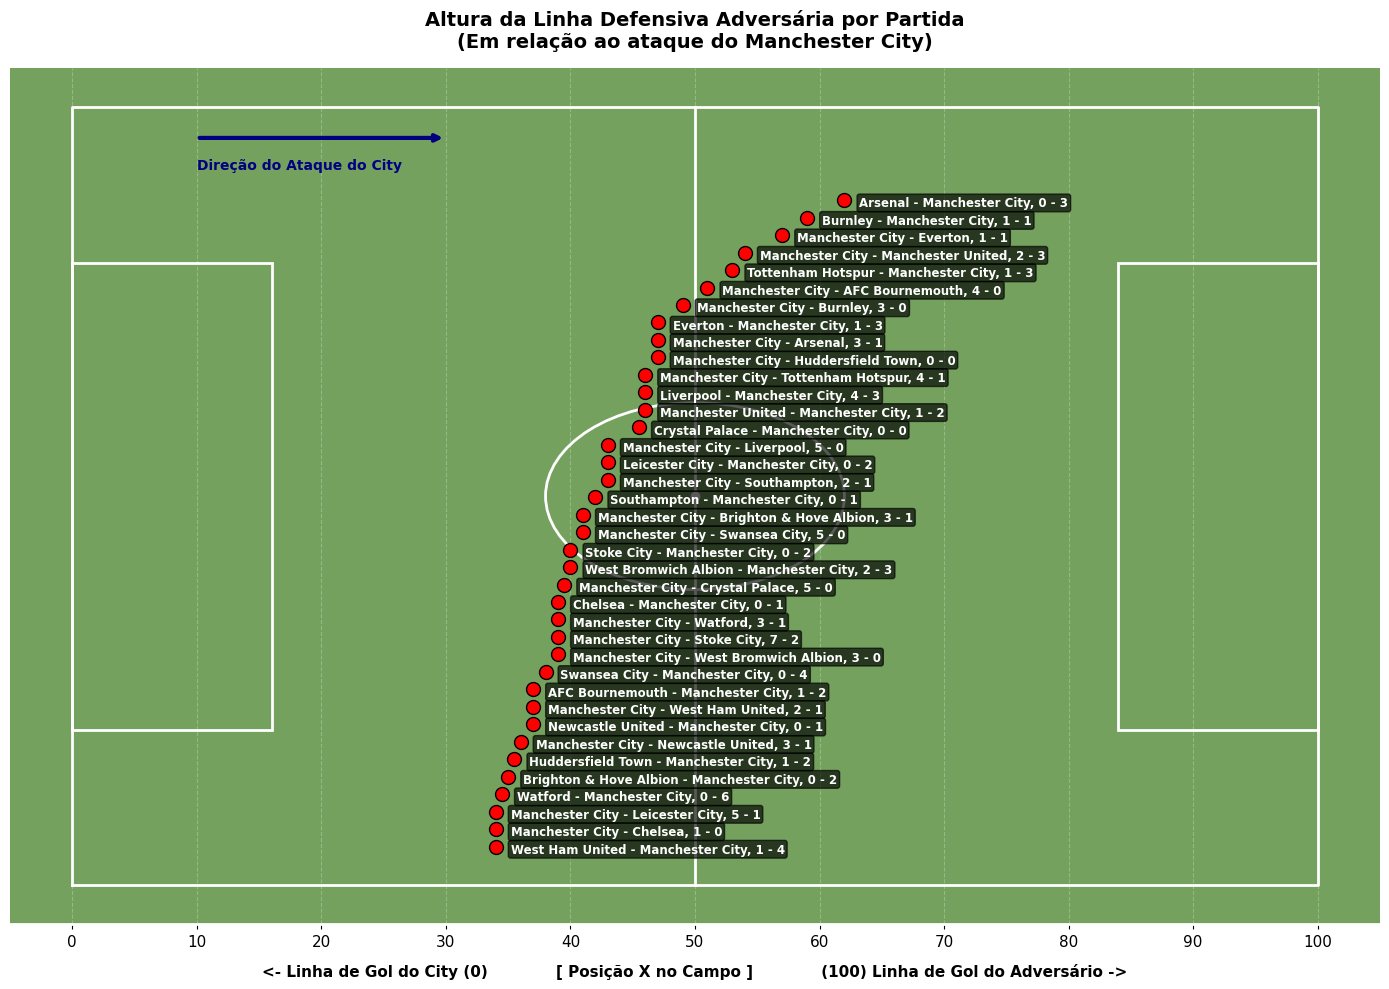

In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# 1. Calcular a posição defensiva média por PARTIDA
def calcula_posicao_media_por_partida(df_events, match_ids, team_id, df_matches):
    dados_partidas = []
    
    # Função auxiliar para pegar o X
    def get_x(positions):
        try: return positions[0]['x']
        except: return None

    for mid in match_ids:
        # Pega a informação e o rótulo exato do confronto (Ex: "Manchester City - Chelsea, 1 - 0")
        match_info = df_matches[df_matches['wyId'] == mid].iloc[0]
        label_jogo = match_info['label'] 

        # Filtra ações defensivas do adversário especificamente nesta partida
        ev_adv = df_events[
            (df_events['matchId'] == mid) & 
            (df_events['teamId'] != team_id) &
            (df_events['eventName'].isin(['Duel', 'Interruption', 'Free Kick']))
        ].copy()
        
        ev_adv['x'] = ev_adv['positions'].apply(get_x)
        mediana_x = ev_adv['x'].median()
        
        if not pd.isna(mediana_x):
            dados_partidas.append({'Partida': label_jogo, 'Posicao_X_Media': mediana_x})
            
    return pd.DataFrame(dados_partidas)

# Executa o cálculo por partida (sem agrupar por time)
df_posicoes_partidas = calcula_posicao_media_por_partida(df_events, city_match_ids, CITY_ID, df_matches)

# Ordena as partidas para que a distribuição vertical no gráfico fique organizada
df_posicoes_partidas = df_posicoes_partidas.sort_values(by='Posicao_X_Media').reset_index(drop=True)

# ==============================================================================
# DESENHANDO O CAMPO DE FUTEBOL E PLOTANDO AS PARTIDAS
# ==============================================================================
fig, ax = plt.subplots(figsize=(14, 10)) # Aumentei um pouco o tamanho para caber os nomes das partidas

# 1. Desenha o gramado (Dimensões do Wyscout: 0 a 100)
ax.set_facecolor('#74a15e') 
plt.xlim(-5, 105)
plt.ylim(-5, 105)

# Linhas do campo
plt.plot([0, 0, 100, 100, 0], [0, 100, 100, 0, 0], color="white", linewidth=2) 
plt.plot([50, 50], [0, 100], color="white", linewidth=2) 

# Círculo central
centro = patches.Circle((50, 50), 12, edgecolor="white", facecolor="none", linewidth=2)
ax.add_patch(centro)
plt.plot(50, 50, "o", color="white")

# Grandes Áreas
ax.add_patch(patches.Rectangle((0, 20), 16, 60, edgecolor="white", facecolor="none", linewidth=2))
ax.add_patch(patches.Rectangle((84, 20), 16, 60, edgecolor="white", facecolor="none", linewidth=2))

# Seta de direção do ataque do City
ax.annotate('', xy=(30, 96), xytext=(10, 96), arrowprops=dict(arrowstyle="->", color="navy", lw=3))
plt.text(10, 92, "Direção do Ataque do City", color="navy", fontsize=10, weight="bold")

# 2. Plotar cada partida individualmente
# Distribui as partidas verticalmente ao longo do campo (eixo Y) para os textos não se sobreporem
y_posicoes = np.linspace(5, 88, len(df_posicoes_partidas))

for idx, row in df_posicoes_partidas.iterrows():
    x_real = row['Posicao_X_Media']
    y_real = y_posicoes[idx]
    
    # Plota o ponto da partida
    plt.scatter(x_real, y_real, color="red", s=100, edgecolors="black", zorder=5)
    
    # Coloca o rótulo da partida (Ex: "Arsenal - Manchester City, 0 - 3") ao lado do ponto
    plt.text(x_real + 1.2, y_real - 0.8, row['Partida'], color="white", 
             fontsize=8.5, weight="bold", bbox=dict(facecolor='black', alpha=0.65, boxstyle='round,pad=0.2'))

# ==============================================================================
# CONFIGURAÇÃO DOS MARCADORES DE POSIÇÃO (LABELS DE 0 A 100)
# ==============================================================================
plt.title("Altura da Linha Defensiva Adversária por Partida\n(Em relação ao ataque do Manchester City)", fontsize=14, weight="bold", pad=15)

# Oculta bordas desnecessárias do gráfico e o eixo Y
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(False)

# Customiza e destaca o eixo X (régua de posições) na parte inferior
ax.spines['bottom'].set_color('white')
ax.spines['bottom'].set_linewidth(2)
ax.xaxis.set_tick_params(colors='black', labelsize=11)

# Força a marcação de 10 em 10 no campo para você saber a posição exata
plt.xticks(np.arange(0, 101, 10))
plt.xlabel("<- Linha de Gol do City (0)             [ Posição X no Campo ]             (100) Linha de Gol do Adversário ->", fontsize=11, weight='bold', labelpad=10)

# Adiciona linhas verticais tracejadas para guiar o olhar até o número de baixo
plt.grid(True, axis='x', color='white', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

In [70]:
# Criar uma função para obter o resultado do City em cada jogo (Vitória, Empate, Derrota)
def get_result(team_id, match_id, df_matches):
    match_info = df_matches[df_matches['wyId'] == match_id].iloc[0]
    teams_data = match_info['teamsData']
    
    # Identificar golos do City e do Adversário
    city_goals = teams_data[str(team_id)]['score']
    opp_id = [tid for tid in teams_data.keys() if int(tid) != team_id][0]
    opp_goals = teams_data[opp_id]['score']
    
    if city_goals > opp_goals:
        return 'Vitória'
    elif city_goals < opp_goals:
        return 'Derrota'
    else:
        return 'Empate'

# Aplica a função no teu DataFrame de correlação que já tem o 'tipo_bloco' ou 'Tipo de Defesa'
df_correlacao['Resultado'] = df_correlacao['matchId'].apply(lambda mid: get_result(CITY_ID, mid, df_matches))

# Agrupa para ver o aproveitamento do City por tipo de bloco
print("=== APROVEITAMENTO DO CITY POR TIPO DE BLOCO ===")
resumo_resultados = df_correlacao.groupby('Tipo de Defesa', observed=False)['Resultado'].value_counts().unstack().fillna(0)
display(resumo_resultados)

=== APROVEITAMENTO DO CITY POR TIPO DE BLOCO ===


Resultado,Derrota,Empate,Vitória
Tipo de Defesa,,,
Bloco Alto,0,0,18
Bloco Médio,1,2,11
Bloco Baixo,1,2,3


In [71]:
def analisa_distancia_passes(df_events, match_ids, team_id):
    dados_passes = []
    
    # Filtra apenas passes do City
    passes_city = df_events[(df_events['matchId'].isin(match_ids)) & (df_events['teamId'] == team_id) & (df_events['eventName'] == 'Pass')].copy()
    
    # Calcula a distância do passe usando as coordenadas de início (positions[0]) e fim (positions[1])
    def calcula_distancia(pos):
        try:
            x1, y1 = pos[0]['x'], pos[0]['y']
            x2, y2 = pos[1]['x'], pos[1]['y']
            return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        except:
            return None

    passes_city['distancia'] = passes_city['positions'].apply(calcula_distancia)
    
    # Média de distância de passe por jogo
    dist_media = passes_city.groupby('matchId')['distancia'].mean().reset_index(name='Distancia_Media_Passe')
    return dist_media

# Junta com a vossa tabela principal
df_dist_passes = analisa_distancia_passes(df_events, city_match_ids, CITY_ID)
df_analise_passes = df_correlacao.merge(df_dist_passes, on='matchId')

print("=== DISTÂNCIA MÉDIA DOS PASSES DO CITY POR TIPO DE BLOCO ===")
display(df_analise_passes.groupby('Tipo de Defesa', observed=False)['Distancia_Media_Passe'].mean())

=== DISTÂNCIA MÉDIA DOS PASSES DO CITY POR TIPO DE BLOCO ===


Tipo de Defesa
Bloco Alto     22.692584
Bloco Médio    22.469222
Bloco Baixo    23.545073
Name: Distancia_Media_Passe, dtype: float64

In [80]:
def analisa_adaptacao_profunda(df_events, match_ids, team_id, df_altura_bloco):
    dados_jogos = []
    
    # Identifica automaticamente o nome da coluna de bloco (seja 'tipo_bloco' ou 'Tipo de Defesa')
    coluna_bloco = 'Tipo de Defesa' if 'Tipo de Defesa' in df_altura_bloco.columns else 'tipo_bloco'
    
    for mid in match_ids:
        # Filtra eventos deste jogo específicos do City e do Adversário
        ev_jogo = df_events[df_events['matchId'] == mid].copy()
        
        ev_city = ev_jogo[ev_jogo['teamId'] == team_id]
        ev_adv = ev_jogo[ev_jogo['teamId'] != team_id]
        
        # 1. Indicadores do City
        total_passes_city = (ev_city['eventName'] == 'Pass').sum()
        total_chutes_city = (ev_city['eventName'] == 'Shot').sum()
        
        # Chutes que foram à baliza (geraram uma tentativa de defesa do guarda-redes adversário)
        chutes_no_alvo = (ev_adv['eventName'] == 'Save attempt').sum() 
        pontaria = (chutes_no_alvo / total_chutes_city * 100) if total_chutes_city > 0 else 0
        
        # 2. Indicadores do Adversário (Como eles tentam parar o City)
        duelos_adv = (ev_adv['eventName'] == 'Duel').sum()
        faltas_cometidas_adv = (ev_adv['eventName'] == 'Foul').sum()
        livres_cantos_city = (ev_city['eventName'] == 'Free Kick').sum() # Cantos/Livres conquistados pelo City
        
        dados_jogos.append({
            'matchId': mid,
            'Passes_City': total_passes_city,
            'Chutes_City': total_chutes_city,
            'Pontaria_City_%': pontaria,
            'Duelos_Adversario': duelos_adv,
            'Faltas_Adversario': faltas_cometidas_adv,
            'Bolas_Paradas_City': livres_cantos_city
        })
        
    df_metricas = pd.DataFrame(dados_jogos)
    
    # Junta com a classificação dos blocos que tu já calculaste
    df_final = df_altura_bloco.merge(df_metricas, on='matchId')
    
    # Retorna o dataframe e o nome correto da coluna para sabermos como agrupar
    return df_final, coluna_bloco

# 1. Executa a nova análise avançada (ajustado para receber o nome correto da coluna)
df_analise_profunda, nome_coluna_bloco = analisa_adaptacao_profunda(df_events, city_match_ids, CITY_ID, altura_bloco)

# 2. Exibe o resumo das médias para cada comportamento tático usando a coluna correta
print("====== MATRIZ DE ADAPTAÇÃO TÁTICA DO MANCHESTER CITY ======")
resumo_tatico = df_analise_profunda.groupby(nome_coluna_bloco, observed=False).agg(
    Jogos=('matchId', 'count'),
    Media_Passes_City=('Passes_City', 'mean'),
    Media_Chutes_City=('Chutes_City', 'mean'),
    Pontaria_Acerto_Percentual=('Pontaria_City_%', 'mean'),
    Duelos_Sofridos=('Duelos_Adversario', 'mean'),
    Faltas_Sofridas=('Faltas_Adversario', 'mean'),
    Bolas_Paradas_Ganhas=('Bolas_Paradas_City', 'mean')
)

# Tenta reordenar os blocos antes de transpor para que fiquem na ordem tática padrão da esquerda para a direita
ordem_colunas = ['Bloco Alto', 'Bloco Médio', 'Bloco Baixo']
if all(item in resumo_tatico.index for item in ordem_colunas):
    resumo_tatico = resumo_tatico.reindex(ordem_colunas)

# Inverte o DataFrame: Linhas viram Colunas e vice-versa (.T faz a transposição)
resumo_tatico_invertido = resumo_tatico.T

display(resumo_tatico_invertido)

====== MATRIZ DE ADAPTAÇÃO TÁTICA DO MANCHESTER CITY ======


Tipo de Defesa,Bloco Alto,Bloco Médio,Bloco Baixo
Jogos,18.000000,14.000000,6.000000
Media_Passes_City,766.888889,709.857143,630.166667
Media_Chutes_City,16.944444,14.857143,15.000000
Pontaria_Acerto_Percentual,47.577620,48.764204,41.435185
Duelos_Sofridos,192.777778,198.500000,196.500000
Faltas_Sofridas,9.333333,11.214286,9.833333
Bolas_Paradas_Ganhas,42.944444,45.571429,47.333333


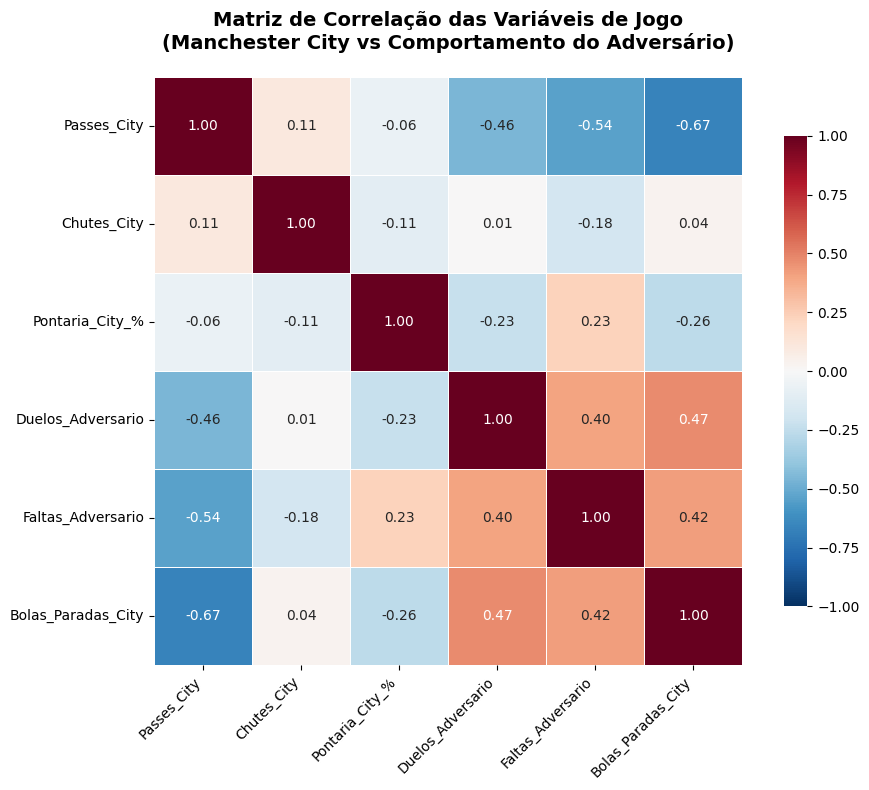

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selecionar apenas as colunas numéricas de desempenho para a correlação
# Removemos o 'matchId' pois o ID do jogo não tem significado matemático
colunas_analise = [
    'Passes_City', 'Chutes_City', 'Pontaria_City_%', 
    'Duelos_Adversario', 'Faltas_Adversario', 'Bolas_Paradas_City'
]

# Calcula a matriz de correlação de Pearson
matriz_corr = df_analise_profunda[colunas_analise].corr()

# ==============================================================================
# DESENHANDO O MAPA DE CALOR (HEATMAP) da CORRELAÇÃO
# ==============================================================================
plt.figure(figsize=(10, 8))

# Criamos o heatmap estilizado
sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra os valores numéricos dentro de cada quadrado
    fmt=".2f",           # Limita para 2 casas decimais
    cmap="RdBu_r",       # Cores: Vermelho para positiva, Azul para negativa (Guardiola aprova o azul!)
    vmin=-1, vmax=1,     # Escala padrão da correlação
    square=True,         # Força os quadrados a serem perfeitamente simétricos
    linewidths=0.5,      # Adiciona uma linha fina separando os blocos
    cbar_kws={"shrink": .8} # Ajusta o tamanho da barra de legenda lateral
)

plt.title("Matriz de Correlação das Variáveis de Jogo\n(Manchester City vs Comportamento do Adversário)", fontsize=14, weight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()